# 07 — 遊脚軌道とCartesian PD

離地から着地までの足軌道と、追従誤差からトルクを作る処理を分けます。

**前提**: `06_foothold_reference.ipynb`

> 読み方: 「直感 → 数式 → 上流コード → 小実験 → 解釈」の順です。
> `実装事実` と書いた箇所は現行 `external/Quadruped-PyMPC` のコード、
> `学習用モデル` は理解のために単純化した再実装です。

In [1]:
# 背景: 各章を同じ作業ディレクトリと依存関係で再実行するには、リポジトリの基準パスと外部実装の場所を最初に固定する必要がある。
# 目的: Quadruped-PyMPCをimport可能にし、acadosとヘッドレスMuJoCoの実行環境を後続セルへ引き渡す。
# ファイルシステム上の基準パスを型安全に扱うためPathを読み込む。
from pathlib import Path
# 環境変数の設定とPythonのモジュール探索パス更新に必要な標準ライブラリを読み込む。
import os, sys

# Notebookを起動した現在位置を絶対パスへ正規化し、教材全体の基準候補とする。
ROOT = Path.cwd().resolve()
# notebook_pympc直下から起動した場合だけ、リポジトリ直下へ基準を1階層戻す。
if ROOT.name == "notebook_pympc":
    # externalディレクトリを参照できるリポジトリ直下へROOTを合わせる。
    ROOT = ROOT.parent
# 上流制御実装が置かれたQuadruped-PyMPCの絶対パスを構成する。
PYMPC_ROOT = ROOT / "external" / "Quadruped-PyMPC"
# 誤った起動位置のまま進まず、依存リポジトリの欠落を具体的なパス付きで検出する。
assert PYMPC_ROOT.exists(), f"Quadruped-PyMPC が見つかりません: {PYMPC_ROOT}"
# 同じパスを重複登録せず、まだimport探索対象でない場合だけ追加する。
if str(PYMPC_ROOT) not in sys.path:
    # ローカルのquadruped_pympcパッケージを通常のimport文で読めるよう探索順の先頭へ置く。
    sys.path.insert(0, str(PYMPC_ROOT))

# acados生成物・共有資源の基準位置を未設定時だけ登録し、利用者の明示設定は上書きしない。
os.environ.setdefault("ACADOS_SOURCE_DIR", str(PYMPC_ROOT / "quadruped_pympc" / "acados"))
# 画面のない環境でもMuJoCoを描画可能にするため、未設定時のOpenGL backendをEGLにする。
os.environ.setdefault("MUJOCO_GL", "egl")
# 実際に採用されたworkspace基準を表示し、相対パス問題を診断できるようにする。
print("workspace :", ROOT)
# import対象となる上流実装の場所を表示し、参照しているコード版を確認可能にする。
print("PyMPC root:", PYMPC_ROOT)

workspace : /home/takuya/work/mpc_dog
PyMPC root: /home/takuya/work/mpc_dog/external/Quadruped-PyMPC


## 軌道生成

現行 `scipy` generatorは5制御点を通るclamped cubic splineです。
中央点のzをstep heightだけ持ち上げ、位置・速度・加速度を返します。

追従加速度は

\[
\ddot p^{cmd}=\ddot p^{ref}
  +K_p(p^{ref}-p)+K_d(\dot p^{ref}-\dot p)
\]

です。`step_height` は幾何、\(K_p,K_d\) は追従ダイナミクスを変えます。

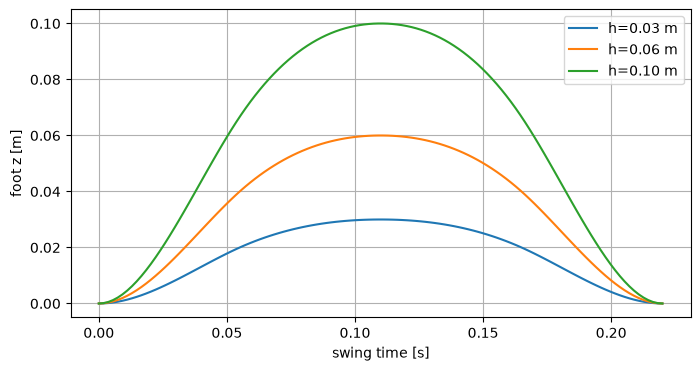

In [2]:
# 背景: 遊脚高さを増やすと障害物余裕は増える一方、同じswing時間では足先速度・加速度が増えるため、軌道形状を時間と単位付きで確認する必要がある。
# 目的: 上流のclamped cubic splineを3つのstep heightで評価し、world座標の足先z[m]をswing時刻[s]に対して比較する。
# 時刻列と3次元足先ベクトルの生成・shape変換にNumPyを使う。
import numpy as np
# 高さ別の軌道を同一図で比較するためpyplotを使う。
import matplotlib.pyplot as plt
# 現行実装と同じ5制御点splineを評価するためSwingTrajectoryGeneratorを読む。
from quadruped_pympc.helpers.swing_generators.scipy_swing_trajectory_generator import SwingTrajectoryGenerator

# 離地x0から着地xfへT秒で移動するworld座標の足軌道。
# 1回の遊脚に割り当てる時間を0.22 sに固定し、高さだけの影響を分離する。
T = 0.22
# 0〜T[s]を120点に分け、splineの時間変化を滑らかに標本化する。
t = np.linspace(0, T, 120)
# 離地点をworld原点のshape (3,)位置[m]として定義する。
lift = np.array([0., 0., 0.])
# 着地点をworld x方向へ0.18 m進んだshape (3,)位置として定義する。
land = np.array([0.18, 0., 0.])
# 3本の高さ曲線を重ねて比較できる8×4 inchの図を作る。
plt.figure(figsize=(8, 4))
# step height h[m]だけを3水準で変え、他条件を固定して比較する。
for h in [0.03, 0.06, 0.10]:
    # 上流は5点 [x0,p1,p2,p3,xf] をclamped cubic splineで結ぶ。
    # zの中央制御点p2_z=(x0_z+xf_z)/2+h が足先頂点を作る。
    # 現在のh[m]と共通swing周期T[s]で上流generatorを構成する。
    gen = SwingTrajectoryGenerator(step_height=h, swing_period=T)
    # 各標本時刻のp_ref shape (3,) [m]を保存する空リストを作る。
    positions = []
    # swing開始から終了までの各時刻で位置・速度・加速度参照を評価する。
    for swing_time in t:
        # 戻り値はp_ref [m], v_ref [m/s], a_ref [m/s^2]。
        # 現在時刻[s]と離地・着地world位置[m]から3種類の参照を計算する。
        p_ref, v_ref, a_ref = gen.compute_trajectory_references(swing_time, lift, land)
        # 可視化に使う位置参照shape (3,)を時系列順に保存する。
        positions.append(p_ref)
    # 位置列をshape (120,3)へ変換し、world z成分[m]だけを取り出す。
    z = np.asarray(positions)[:, 2]
    # 現在のhを凡例へ含め、z(t)を他の高さと同じ軸へ描く。
    plt.plot(t, z, label=f"h={h:.2f} m")
# 横軸がswing内の経過時間[s]であることを明示する。
plt.xlabel("swing time [s]"); plt.ylabel("foot z [m]")  # 縦軸がworld足先高さ[m]であることも明示する。
# 高さ別曲線を識別する凡例を追加する。
plt.legend(); plt.grid(); plt.show()  # 格子を付けた完成図をNotebookへ描画する。

In [3]:
# 背景: Cartesian PDの補正項Kp e_p+Kd e_vは、同じ足先誤差でもgain設定に比例して大きくなり、後段の加速度・トルク要求を変える。
# 目的: 固定した3軸位置誤差[m]と速度誤差[m/s]に3組のgainを適用し、補正加速度相当量の増加を比較する。
# 同じ1 cmの位置誤差でもKpで補正力相当量が変わる
# world xyzの足先位置誤差e_p=p_ref-pをshape (3,) [m]で定義する。
e_p = np.array([0.01, -0.01, 0.02])
# world xyzの足先速度誤差e_v=v_ref-vをshape (3,) [m/s]で定義する。
e_v = np.array([0.1, 0.0, -0.1])
# 低・中・高の(Kp,Kd)組を順に適用し、誤差を固定したgain感度を調べる。
for kp, kd in [(100, 5), (500, 10), (800, 20)]:
    # a_corr=Kp e_p+Kd e_vにより3軸の補正加速度相当量を計算する。
    correction = kp * e_p + kd * e_v
    # 使用gainとshape (3,)の補正結果を同じ行へ表示し、増幅度を比較する。
    print(f"Kp={kp:3}, Kd={kd:2}: correction={correction}")

Kp=100, Kd= 5: correction=[ 1.5 -1.   1.5]
Kp=500, Kd=10: correction=[ 6. -5.  9.]
Kp=800, Kd=20: correction=[10. -8. 14.]


高さを上げれば安全とは限りません。同じswing時間で高くすると速度・加速度ピークが増え、
Jacobian変換後トルクが飽和しやすくなります。クリアランス不足とトルク飽和を
同時にログして選びます。

## 章末チェック

出力を眺めるだけでなく、次を自分の言葉で答えてください。

1. この章の入力・出力の shape、単位、座標系は何か。
2. 変更可能な量と、他の章から渡される量は何か。
3. パラメータを2倍にしたとき、どのグラフがどちらへ変化するか。
4. 現行実装の事実と、学習用の近似を区別できるか。